### 이상치
- 값이 이상한 데이터를 의미
    - 결측치
    - 범위에서 벗어나는 데이터
    - 값이 크게 벗어나는 데이터
- 분석 모델의 성능을 떨어뜨리거나 결과에 악영향을 미치는 경우가 발생
- 이상치 데이터 발견시 즉시 처리
    - 데이터를 제거
        - 소량의 데이터에서 데이터를 제거하는 부분에서는 학습 데이터가 부족해지는 경우가 발생
        - 이상치 데이터가 너무 많은 경우 많은 양의 데이터가 제거
    - 특정 값으로 대체
        - 데이터의 양은 보존
        - 평균값을 대체하거나 최빈값으로 대체 (일반적)
        - 데이터가 신뢰도 하락 가능성이 존재
        - 분석의 성능이 떨어지는 경우가 발생
        - 데이터의 분포도가 과밀화가 종종 발생
- 결측치를 확인하는 방법
    - isna() 함수를 이용하여 결측치의 유무를 판단
    - sum() 함수를 이용하여 결측치의 개수를 확인
    - info() 함수를 이용하여 non-null count를 확인
- 특정 범위를 벗어나는 데이터를 확인하는 방법
    - unique() 함수를 이용하여 특정 필드의 유일 데이터를 확인
    - value_counts() 함수를 이용하여 특정 필드의 데이터들의 빈도수를 확인
    - isin() 함수를 이용하여 특정 값들에 포함되어있는가를 확인하고 부정연산자(비트연산자(~))를 이용하여 데이터를 확인
- 극단치( 값이 크게 벗어나느 데이터 )를 확인하는 방법
    - IQR 방식
        - boxplot()의 수염의 경계
        - Q3(3사분위수)와 Q1(1사분위수)를 이용하여 극단치의 범위를 지정
        - IQR = Q3 - Q1
        - 극단치의 경계
            - 상단의 경계 : Q3 + 1.5 * IQR
            - 하단의 경계 : Q1 - 1.5 * IQR
        - 상단의 경계보다 크거나 하단의 경우보다 작은 경우 극단치로 판단

In [ ]:
# 사이킷런 라이브러리 설치
# !pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

In [3]:
# 사이킷런에서 제공하는 샘플 와인 데이터를 로드
wine_data = load_wine()

In [5]:
wine_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

- scikit-learn 샘플 데이터의 key
    - data
        - 독립변수( 데이터 )
        - 머신러닝에서 학습 데이터로 사용하는 부분
    - target
        - 종속변수( 데이터 )
        - 머신러닝에서 정답 데이터로 사용하는 부분
    - frame
        - 독립변수와 종속변수 데이터를 모두 포함하여 데이터프레임으로 제공
        - 데이터가 존재하지 않는 경우도 있음
    - target_names
        - 종속 변수들의 의미
    - DESCR
        - 데이터의 정보를 확인
    - feature_names
        - 피처(컬럼)의 이름을 확인

In [6]:
# 데이터의 정보 확인
wine_data['DESCR']

'.. _wine_dataset:\n\nWine recognition dataset\n------------------------\n\n**Data Set Characteristics:**\n\n    :Number of Instances: 178\n    :Number of Attributes: 13 numeric, predictive attributes and the class\n    :Attribute Information:\n \t\t- Alcohol\n \t\t- Malic acid\n \t\t- Ash\n\t\t- Alcalinity of ash  \n \t\t- Magnesium\n\t\t- Total phenols\n \t\t- Flavanoids\n \t\t- Nonflavanoid phenols\n \t\t- Proanthocyanins\n\t\t- Color intensity\n \t\t- Hue\n \t\t- OD280/OD315 of diluted wines\n \t\t- Proline\n\n    - class:\n            - class_0\n            - class_1\n            - class_2\n\t\t\n    :Summary Statistics:\n    \n    ============================= ==== ===== ======= =====\n                                   Min   Max   Mean     SD\n    ============================= ==== ===== ======= =====\n    Alcohol:                      11.0  14.8    13.0   0.8\n    Malic Acid:                   0.74  5.80    2.34  1.12\n    Ash:                          1.36  3.23    2.36  0.27\

In [7]:
# frame을 제공하는가?
wine_data['frame']

In [10]:
# data, feature_names 데이터를 이용하여 데이터프레임 생성
wine = pd.DataFrame(
    data = wine_data['data'],
    columns = wine_data['feature_names']
)

In [11]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [13]:
# 종속변수도 데이터프레임에 추가
# target_data
wine['class'] = wine_data['target']

In [14]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [15]:
# target 데이터의 의미는 target_names
wine_data['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [16]:
# 결측치 확인
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

In [18]:
# class 데이터에서 0,1,2를 제외한 데이터가 존재하는가?
# case1 : unique()
wine['class'].unique()

array([0, 1, 2])

In [19]:
# case2 : value_counts()
wine['class'].value_counts()

class
1    71
0    59
2    48
Name: count, dtype: int64

In [21]:
# case3 : isin() 함수를 활용
wine['class'].isin([0,1,2]).sum()

178

In [22]:
flag = wine['class'].isin([0,1,2])
# 비트 연산자를 이용하여 부정
wine.loc[~flag,]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class


In [23]:
# 극단치 데이터를 확인
# describe() 함수
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


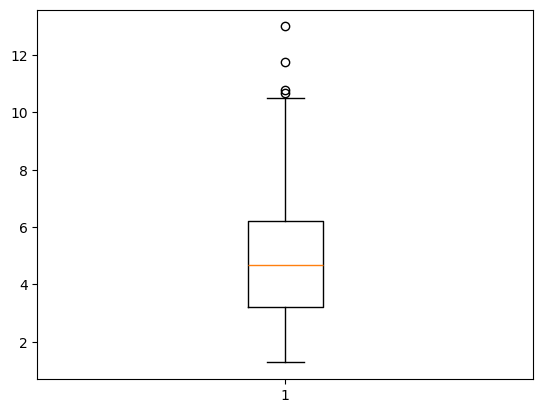

In [24]:
# boxplot() 함수를 이용하여 극단치 경계에서 벗어나는 데이터가 존재하는가?
# 특정 컬럼(color_intensity)를 이용하여 확인
plt.boxplot(wine['color_intensity'])
plt.show()

In [ ]:
# 3사분위수(75%) 출력 -> describe() 함수를 이용해서 추출 가능
wine['color_intensity'].describe()['25%']

3.2199999999999998

In [33]:
# numpy 라이브러리를 이용해서 사분위수를 출력이 가능
# percentile() : 첫번째 인자는 데이터들 // 두번째 인자에는 몇퍼센트의 값들을 선택
q1, q3 = np.percentile(wine['color_intensity'], [25,75])

In [34]:
q1

3.2199999999999998

In [36]:
q3

6.2

In [37]:
# IQR 계산
iqr = q3 - q1
# 상단 경계 계산 : 3사분위수 + (1.5 * IQR)
upper_whis = q3 + 1.5 * iqr
# 하단 경계 계산 : 1사분위수 + (1.5 * IQR)
lower_whis = q1 - 1.5 * iqr
print(upper_whis, lower_whis)

10.670000000000002 -1.2500000000000009


In [38]:
# 극단치 : 상단의 경계보다 크거나 하단의 경계보다 작은 경우
upper_flag = wine['color_intensity'] > upper_whis
lower_flag = wine['color_intensity'] < lower_whis

In [39]:
wine.loc[upper_flag | lower_flag, ]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
151,12.79,2.67,2.48,22.0,112.0,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480.0,2
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2


In [40]:
# 데이터프레임을 복사
df = wine.copy()

In [44]:
# df 데이터프레임에서는 극단치를 제거
# drop() 함수를 이용해서 해당 인덱스를 제거
# 극단치의 경계식에 부정(비트연산자)하여 필터링
# 극단치의 데이터를 결측치로 대체하고 결측치를 제거하는 함수
    # 특정 컬럼의 데이터들을 결측치로 대체하고 결측치의 제거함수(dropna())를 이용하여 삭제

whis_idx = df.loc[upper_flag | lower_flag, ].index

df.drop(whis_idx, axis = 0)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [45]:
df.loc[~(upper_flag | lower_flag), ]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [48]:
df.loc[upper_flag | lower_flag, 'color_intensity'] = np.nan

In [49]:
df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 4
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
class                           0
dtype: int64

In [50]:
df.dropna(axis = 0)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [51]:
# 극단치 데이터들을 다른 값으로 대체
# 극단치 상단의 경계에서 벗어난 데이터는 상단의 경계 값으로 채워주고
# 하단의 경계에서 벗어난 데이터는 하단의 경계 값으로 채워준다

# 상단 경계에서 벗어난 데이터를 확인
df2 = wine.copy()
df2.loc[upper_flag,]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
151,12.79,2.67,2.48,22.0,112.0,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480.0,2
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2


In [54]:
# 경계엣 벗어난 데이터는 상단의 경계값으로 대체
df2.loc[upper_flag, 'color_intensity'] = upper_whis
df2.loc[lower_flag, 'color_intensity'] = lower_whis

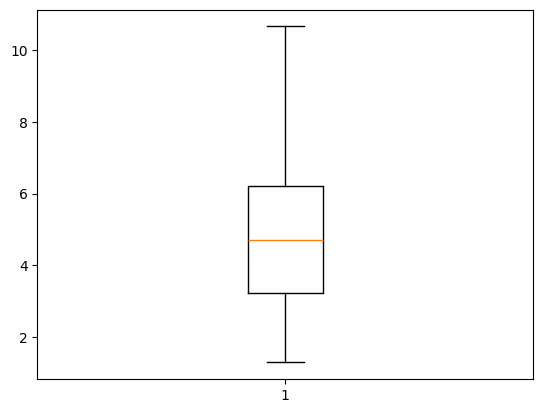

In [55]:
plt.boxplot(df2['color_intensity'])
plt.show()

- 극단치의 데이터를 확인하고 대체하거나 제거하는 함수를 생성
    - 원본의 데이터를 그대로 유지한 상태에서 데이터를 제공하는 함수
    - 매개변수 3개
        - data -> 필수 항목 -> 데이터프레임
        - col -> 필수 항목 -> 극단치 데이터를 확인하려는 컬럼의 이름
        - n -> 기본값 1.5 지정 -> 극단치의 경계 범위를 지정
        - drop -> 기본값 False -> 결측치 데이터를 제거할것인가 채워줄것인가
    - 지정이 된 컬럼을 선택하여 1, 3 사분위수를 계산
    - IQR 생성
    - n의 값을 이용하여 상단의 경계, 하단의 경계 생성
    - 상단의 경계에서 벗어나는 데이터의 개수를 출력
    - 하단의 경계에서 벗어사는 데이터의 개수를 출력
    - drop 의 값에 따라 지울 것인가, 대체할것인가 지정
    - 결과물인 데이터프레임을 되돌려준다


In [68]:
# 수정작업(2026.0506) : 2번째 매개변수 컬럼 값을 가변 인자로 변경 (col -> cols로 변경)
# def outlier_iqr(data, col, n = 1.5, drop = False):
def outlier_iqr(data, *cols, n = 1.5, drop = False):
    # 원본의 데이터를 그대로 유지하기 위해서 복사
    df = data.copy()
    # 입력으로 받은 데이터프레임 안에 col의 값이 컬럼으로 존재하는가? -> 해당 컬럼의 데이터 타입이 숫자인가?
    # if col in df.columns:
    # 우선 실행한다 에러가 발생하면 예외 처리 한다 try ~ except
    # 수정작업 1차 cols를 사용하면 반복문 추가
    # 경계에서 벗어난 데이터프레임들을 dict 형태로 되돌려준다. {col : DataFrame, col2 : DataFrame}
    whis_dict = {}
    for col in cols:
        try:
            # 1, 3 사분위수를 계산
            q_1, q_3 = np.percentile(df[col],[25,75])
            iqr = q_3 - q_1

            # 상단의 경계, 하단의 경계 값 계산
            upper_whis = q_3 + n * iqr
            lower_whis = q_1 - n * iqr
            # 경계값들 출력
            print(f"""
                지정된 컬럼의 이름 : {col},
                상단의 경계 값: {upper_whis},
                하단의 경계값 : {lower_whis}
            """)

            # 상단의 경계를 벗어나는 데이터의 개수 확인
            upper_flag = df[col] > upper_whis
            lower_flag = df[col] < lower_whis
            upper_n = len(df.loc[upper_flag,])
            lower_n = len(df.loc[lower_flag,])
            print(f" 상단의 경계를 벗어나는 데이터 개수 : {upper_n} 하단의 경계를 벗어나는 데이터 개수 : {lower_n}")

            # 극단치의 경계에서 벗어난 데이터들
            whis_df = df.loc[ upper_flag | lower_flag,]
            # whis_df를 whis_dict에 추가
            whis_dict[col] = whis_df

            if drop:
                # 극단치를 제거
                df = df.loc[~(upper_flag | lower_flag),]
            else:
                df.loc[upper_flag, col] = upper_whis
                df.loc[lower_flag, col] = lower_whis

            # 결과물, 극단치의 경계에서 벗어난 데이터들을 되돌려준다
            # return df, whis_df
        
        except Exception as e:
            print(f'Error : {e}')

    return df, whis_dict


In [73]:
df3, whis_df = outlier_iqr(wine, 'color_intensity', 'ash', drop = True)


                지정된 컬럼의 이름 : color_intensity,
                상단의 경계 값: 10.670000000000002,
                하단의 경계값 : -1.2500000000000009
            
 상단의 경계를 벗어나는 데이터 개수 : 4 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : ash,
                상단의 경계 값: 3.035,
                하단의 경계값 : 1.7149999999999999
            
 상단의 경계를 벗어나는 데이터 개수 : 2 하단의 경계를 벗어나는 데이터 개수 : 4


In [74]:
df3

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [75]:
whis_df

{'color_intensity':      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 151    12.79        2.67  2.48               22.0      112.0           1.48   
 158    14.34        1.68  2.70               25.0       98.0           2.80   
 159    13.48        1.67  2.64               22.5       89.0           2.60   
 166    13.45        3.70  2.60               23.0      111.0           1.70   
 
      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 151        1.36                  0.24             1.26            10.80  0.48   
 158        1.31                  0.53             2.70            13.00  0.57   
 159        1.10                  0.52             2.29            11.75  0.57   
 166        0.92                  0.43             1.46            10.68  0.85   
 
      od280/od315_of_diluted_wines  proline  class  
 151                          1.47    480.0      2  
 158                          1.96    660.0      2  
 159    

In [76]:
df4 , whis_dict = outlier_iqr(wine, *wine.columns, drop = True)


                지정된 컬럼의 이름 : alcohol,
                상단의 경계 값: 15.650000000000002,
                하단의 경계값 : 10.389999999999997
            
 상단의 경계를 벗어나는 데이터 개수 : 0 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : malic_acid,
                상단의 경계 값: 5.3025,
                하단의 경계값 : -0.6174999999999997
            
 상단의 경계를 벗어나는 데이터 개수 : 3 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : ash,
                상단의 경계 값: 3.0724999999999993,
                하단의 경계값 : 1.6925000000000003
            
 상단의 경계를 벗어나는 데이터 개수 : 2 하단의 경계를 벗어나는 데이터 개수 : 1

                지정된 컬럼의 이름 : alcalinity_of_ash,
                상단의 경계 값: 27.987499999999997,
                하단의 경계값 : 10.687500000000002
            
 상단의 경계를 벗어나는 데이터 개수 : 2 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : magnesium,
                상단의 경계 값: 135.5,
                하단의 경계값 : 59.5
            
 상단의 경계를 벗어나는 데이터 개수 : 3 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : total_phenols,
                상단의 경계

In [77]:
df4

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,14.16,2.51,2.48,20.0,91.0,1.68,0.70,0.44,1.24,9.70,0.62,1.71,660.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [79]:
whis_dict

{'alcohol': Empty DataFrame
 Columns: [alcohol, malic_acid, ash, alcalinity_of_ash, magnesium, total_phenols, flavanoids, nonflavanoid_phenols, proanthocyanins, color_intensity, hue, od280/od315_of_diluted_wines, proline, class]
 Index: [],
 'malic_acid':      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
 123    13.05        5.80  2.13               21.5       86.0           2.62   
 137    12.53        5.51  2.64               25.0       96.0           1.79   
 173    13.71        5.65  2.45               20.5       95.0           1.68   
 
      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
 123        2.65                  0.30             2.01              2.6  0.73   
 137        0.60                  0.63             1.10              5.0  0.82   
 173        0.61                  0.52             1.06              7.7  0.64   
 
      od280/od315_of_diluted_wines  proline  class  
 123                          3.10    38

### 범주형 데이터의 변환
- 범주형 변수는 학습 모델이 대부분 수학적인 연산으로 모델을 생성하는데 직접적으로 사용이 어렵기 때문에 특별 가공처리
- 더미 변수 생성
    - 범주형 데이터를 각각의 컬럼으로 생성
    - 0과 1로 데이터를 대입하여 포함 여부를 생성

In [81]:
# class 컬럼의 값들을 범주형 데이터 변환
wine_data['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [83]:
wine['class'].map(
    lambda x : wine_data['target_names'][x]
)

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Name: class, Length: 178, dtype: object

In [87]:
# map() 함수 안에 dict 데이터 대입
wine['class'] = wine['class'].map(
    {
        0 : 'class_0',
        1 : 'class_1',
        2 : 'class_2'
    }
)

In [86]:
# list 형태의 데이터를 dict 형태로 변환이 가능할까?
dict_data = {}
for i in range(len(wine_data['target_names'])):
    dict_data[i] = wine_data['target_names'][i]
dict_data

{0: 'class_0', 1: 'class_1', 2: 'class_2'}

In [88]:
wine['class'].value_counts()

class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

In [90]:
# 더미 변수들을 생성
# get + dumies -> get_dumies() [pandas에 내장된 함수]
dumie_df = pd.get_dummies(wine, columns=['class'])

In [93]:
dumie_df['class_class_2'].sum()

48